# Algoritmo Genético com DEAP

Este notebook resolve o **Problema da Mochila** (Knapsack Problem) usando a biblioteca [DEAP](https://deap.readthedocs.io/) (*Distributed Evolutionary Algorithms in Python*).

O objetivo é selecionar os produtos com maior valor total que cabem em um caminhão com espaço limitado de **3 m³**.

## Comparação com `01_genetic_algorithm.ipynb`

| Aspecto | `01_genetic_algorithm.ipynb` | `02_ga_deap.ipynb` (este) |
|---|---|---|
| Implementação | Manual (do zero) | Com a biblioteca DEAP |
| Crossover | Implementado manualmente | `tools.cxOnePoint` |
| Mutação | Implementada manualmente | `tools.mutFlipBit` |
| Seleção | Implementada manualmente | `tools.selRoulette` |
| Loop evolutivo | Manual | `algorithms.eaSimple` |

A lógica do problema é idêntica — a diferença está em como as operações genéticas são expressas.

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from deap import base       # Toolbox: registra e organiza os operadores
from deap import creator    # Cria classes de fitness e indivíduo em tempo de execução
from deap import algorithms # Algoritmos evolutivos prontos (ex: eaSimple)
from deap import tools      # Operadores genéticos: crossover, mutação, seleção, estatísticas

## 1. Carregamento dos Dados

Os produtos disponíveis para carregar no caminhão estão armazenados em `produtos.csv`, com três atributos:
- **nome**: identificação do produto
- **espaco**: volume ocupado (em m³)
- **valor**: valor monetário do produto (R$)

In [48]:
df_produtos = pd.read_csv("produtos.csv")
df_produtos

,nome,espaco,valor
0,Geladeira Dako,0.75100,999.90
1,Iphone 6,0.00009,2199.12
2,TV 55',0.40000,4346.99
3,TV 50',0.29000,3999.90
4,TV 42',0.20000,2999.00
5,Notebook Dell,0.00350,2499.90
6,Ventilador Panasonic,0.49600,199.90
7,Microondas Electrolux,0.04240,308.66
8,Microondas LG,0.05440,429.90
9,Microondas Panasonic,0.03190,299.29


## 2. Configuração do DEAP

O DEAP organiza o algoritmo genético em torno de um `Toolbox`, que centraliza a representação dos indivíduos e as operações genéticas.

### Representação do Indivíduo
Cada indivíduo é um vetor binário de tamanho `n_produtos`. Se a posição `i` for `1`, o produto `i` está selecionado; se for `0`, está excluído.

### Fitness
`FitnessMax` com `weights=(1.0,)` indica que queremos **maximizar** um único objetivo. Pesos negativos seriam usados para minimização.

In [ ]:
produtos = df_produtos["nome"].to_list()
espacos = df_produtos["espaco"].to_list()
valores = df_produtos["valor"].to_list()
limite_espacos = 3  # capacidade máxima do caminhão em m³

toolbox = base.Toolbox()

# FitnessMax: objetivo de maximização (weight positivo)
creator.create("FitnessMax", base.Fitness, weights=(1.0, ))
# Individual: lista Python com atributo fitness associado
creator.create("Individual", list, fitness=creator.FitnessMax)

# Gera um gene binário aleatório (0 ou 1)
toolbox.register("attr_bool", random.randint, 0, 1)
# Constrói um indivíduo repetindo attr_bool n vezes (um gene por produto)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=len(espacos))
# Constrói a população como uma lista de indivíduos
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

## 3. Função de Avaliação (Fitness)

A função de avaliação determina a qualidade de cada indivíduo:
- Soma o valor dos produtos selecionados (`individual[i] == 1`)
- Se o espaço total ultrapassar o limite, penaliza com `nota = 0` (solução inviável)
- Retorna uma tupla `(nota / 100_000,)` — o DEAP sempre espera um iterável como retorno

> O divisor `100_000` é apenas uma normalização para manter os valores em escala reduzida.

In [ ]:
def avaliacao(individual):
    """
    Avalia a aptidão (fitness) de um indivíduo.

    Calcula o valor total dos produtos selecionados. Se o espaço total
    exceder o limite, a nota é zerada (solução inviável).

    Args:
        individual: lista binária onde 1 indica que o produto foi selecionado.

    Returns:
        tuple: (fitness,) — valor total normalizado, ou (0,) se inviável.
    """
    nota = 0
    soma_espacos = 0
    
    for i in range(len(individual)):
        if individual[i] == 1:
            nota += valores[i]
            soma_espacos += espacos[i]
    
    # Penalidade: soluções que excedem o limite de espaço são descartadas
    if soma_espacos > limite_espacos:
        nota = 0
    
    return (nota / 100_000,)

## 4. Registro dos Operadores Genéticos

Os operadores são registrados no `toolbox`, desacoplando a definição do uso:

| Operador | Função DEAP | Descrição |
|---|---|---|
| `evaluate` | `avaliacao` | Calcula o fitness de cada indivíduo |
| `mate` | `tools.cxOnePoint` | Cruzamento de um ponto: troca segmentos entre dois pais |
| `mutate` | `tools.mutFlipBit` | Mutação: inverte cada bit com probabilidade `indpb` |
| `select` | `tools.selRoulette` | Seleção por roleta — indivíduos com maior fitness têm maior chance de ser escolhidos |

In [ ]:
toolbox.register("evaluate", avaliacao)                   # função de fitness
toolbox.register("mate", tools.cxOnePoint)                 # cruzamento de 1 ponto
toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)   # mutação bit-flip com prob. 1% por gene
toolbox.register("select", tools.selRoulette)              # seleção proporcional ao fitness

## 5. Execução do Algoritmo

O `algorithms.eaSimple` executa o loop evolutivo completo:

1. Avalia a população inicial
2. Para cada geração: seleciona pais → aplica crossover → aplica mutação → avalia filhos
3. Retorna a população final e um `Logbook` com as estatísticas por geração

### Parâmetros

| Parâmetro | Valor | Descrição |
|---|---|---|
| `n` | 20 | Tamanho da população |
| `cxpb` | 1.0 | Probabilidade de cruzamento (100% dos pares) |
| `mutpb` | 0.01 | Probabilidade de mutação por indivíduo |
| `ngen` | 100 | Número de gerações |

In [ ]:
populacao = toolbox.population(n=20)        # 20 indivíduos na população inicial
probabilidade_crossover = 1.0               # todos os pares de pais se cruzam
probabilidade_mutacao = 0.01                # 1% de chance de mutação por indivíduo
numero_geracoes = 100

# Estatísticas coletadas a cada geração para acompanhar a evolução
estatisticas = tools.Statistics(key=lambda individuo: individuo.fitness.values)
estatisticas.register("max", np.max)
estatisticas.register("min", np.min)
estatisticas.register("med", np.mean)
estatisticas.register("std", np.std)

# eaSimple: loop evolutivo padrão (seleção → cruzamento → mutação → avaliação)
# Retorna a população final e o logbook com as estatísticas por geração
populacao, info = algorithms.eaSimple(populacao, toolbox, probabilidade_crossover, probabilidade_mutacao, numero_geracoes, estatisticas)

## 6. Visualização da Evolução

O gráfico abaixo mostra a progressão do **melhor fitness** ao longo das gerações, evidenciando a convergência do algoritmo para a solução ótima.

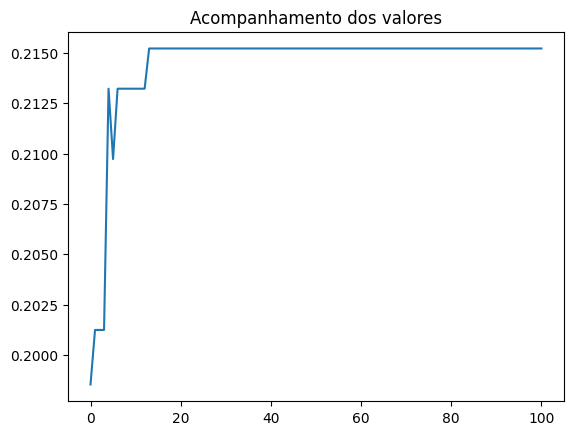

In [53]:
plt.plot(info.select("max"))
plt.title("Acompanhamento dos valores")
plt.show()

## Conclusão

O algoritmo convergiu para a melhor combinação de produtos respeitando o limite de espaço de **3 m³**.

A curva de evolução confirma o comportamento típico de um algoritmo genético:
1. **Exploração inicial**: grande variação nas primeiras gerações
2. **Convergência**: a população se concentra em soluções de alto fitness
3. **Estabilização**: o máximo se mantém constante quando a população converge

Comparado à implementação manual (`01_genetic_algorithm.ipynb`), o uso do DEAP elimina o boilerplate do loop evolutivo, mantendo o mesmo resultado final com menos código.